# 🛡️ NovaPay · EDA
### Datos Sintéticos de Transacciones Financieras — Detección de Fraude

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [2]:
"C:/Users/Usuario/Desktop/synthetic_data_FULL.csv"

'C:/Users/Usuario/Desktop/synthetic_data_FULL.csv'

In [3]:
df = pd.read_csv("C:/Users/Usuario/Desktop/synthetic_data_FULL.csv")

In [4]:
df.shape

(6362620, 11)

In [5]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [6]:
legit = df[df["isFraud"] == 0].sample(n = 265000, random_state = 42)
fraud = df[df["isFraud"] == 1]

In [7]:
df_balanced = pd.concat([legit, fraud]).reset_index(drop = True)

In [8]:
# df_balanced.to_csv('../data/synthetic_fin_data_RAW.csv', index = False)

In [9]:
df_eda = pd.read_csv('../data/synthetic_fin_data_RAW.csv')

In [10]:
df_eda["isFraud"].value_counts()

isFraud
0    265000
1      8213
Name: count, dtype: int64

In [11]:
df_eda.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,162,CASH_OUT,183806.32,C691771226,19391.00,0.00,C1416312719,382572.19,566378.51,0,0
1,137,PAYMENT,521.37,C203378011,0.00,0.00,M42773300,0.00,0.00,0,0
2,179,PAYMENT,3478.18,C1698571270,19853.00,16374.82,M643984524,0.00,0.00,0,0
3,355,PAYMENT,1716.05,C913764937,5769.17,4053.13,M1387429131,0.00,0.00,0,0
4,354,CASH_IN,253129.93,C2017736577,1328499.49,1581629.42,C407484102,2713220.48,2460090.55,0,0


In [35]:
df_eda[df_eda['amount'] == df_eda['amount'].max()]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour_of_the_day,ip_country,merchant_category,balance_discrepancy
19403,286,TRANSFER,69886731.3,C1425667947,0.0,0.0,C167875008,1.515387e+08,2.214254e+08,0,22,GB,restaurant,-69886731.3


In [12]:
df_eda = df_eda.drop(columns = "isFlaggedFraud")

In [13]:
df_eda["hour_of_the_day"] = df_eda["step"] % 24

In [14]:
df_eda.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour_of_the_day
0,162,CASH_OUT,183806.32,C691771226,19391.00,0.00,C1416312719,382572.19,566378.51,0,18
1,137,PAYMENT,521.37,C203378011,0.00,0.00,M42773300,0.00,0.00,0,17
2,179,PAYMENT,3478.18,C1698571270,19853.00,16374.82,M643984524,0.00,0.00,0,11
3,355,PAYMENT,1716.05,C913764937,5769.17,4053.13,M1387429131,0.00,0.00,0,19
4,354,CASH_IN,253129.93,C2017736577,1328499.49,1581629.42,C407484102,2713220.48,2460090.55,0,18


In [15]:
high_risk_countries = ['KH', 'CN', 'VE', 'CI', 'NG']
low_risk_countries = ['ES', 'US', 'DE', 'FR', 'GB']

df_eda['ip_country'] = df_eda['isFraud'].apply(
    lambda x: np.random.choice(high_risk_countries) 
    if (x == 1 and np.random.random() < 0.6) 
    else np.random.choice(low_risk_countries)
)

In [16]:
high_risk_categories = ['crypto', 'electronics']
low_risk_categories = ['grocery', 'restaurant', 'pharmacy', 'fuel', 'transport']

df_eda['merchant_category'] = df_eda['isFraud'].apply(
    lambda x: np.random.choice(high_risk_categories)
    if (x == 1 and np.random.random() < 0.65)
    else np.random.choice(low_risk_categories)
)

In [17]:
df_eda.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour_of_the_day,ip_country,merchant_category
0,162,CASH_OUT,183806.32,C691771226,19391.00,0.00,C1416312719,382572.19,566378.51,0,18,FR,grocery
1,137,PAYMENT,521.37,C203378011,0.00,0.00,M42773300,0.00,0.00,0,17,FR,restaurant
2,179,PAYMENT,3478.18,C1698571270,19853.00,16374.82,M643984524,0.00,0.00,0,11,ES,transport
3,355,PAYMENT,1716.05,C913764937,5769.17,4053.13,M1387429131,0.00,0.00,0,19,GB,restaurant
4,354,CASH_IN,253129.93,C2017736577,1328499.49,1581629.42,C407484102,2713220.48,2460090.55,0,18,DE,grocery


## 🛠️ Data Quality Fix — Balancing Fraud Rate by Country
### Generating synthetic legitimate transactions for overrepresented fraud countries

In [42]:
# Ranking de países fraudulentos
# CI, CN, NG, VE & KH tienen un 100% de tasa de fraude

df_eda.groupby("ip_country")["isFraud"].mean().sort_values(ascending=False).head(20)

ip_country
CI    1.000000
CN    1.000000
NG    1.000000
VE    1.000000
KH    1.000000
US    0.012706
FR    0.012190
ES    0.012052
DE    0.011812
GB    0.011158
Name: isFraud, dtype: float64

In [ ]:
# Transacciones fraudulentas por país

df_eda[df_eda["isFraud"] == 1].groupby("ip_country")["isFraud"].count() 

ip_country
CI    1012
CN    1002
DE     635
ES     648
FR     651
GB     599
KH    1007
NG     981
US     681
VE     997
Name: isFraud, dtype: int64

In [ ]:
# ── Países a corregir y sus conteos de fraude ──────────────────────────────────
problem_countries = ["CI", "CN", "NG", "VE", "KH"]

# ── Usar transacciones legítimas como base estadística───────────────────────────
legit = df_eda[df_eda["isFraud"] == 0]

In [45]:
new_rows = []

for country in problem_countries:
    
    # Cuántas líneas de fraude tiene cada país
    n_fraud = len(df_eda[(df_eda["ip_country"] == country) & (df_eda["isFraud"] == 1)])
    
    # Filas legítimas a generar = 3x líneas fraude
    n_legit = n_fraud * 3
    
    for _ in range(n_legit):
        
        # Muestrear el importe de la distribución de transacciones legítimas
        amount = max(10.0, np.random.normal(legit["amount"].mean(), legit["amount"].std()))
        amount = round(min(amount, 500_000), 2)
        
        # Muestrear los saldos de la distribución de transacciones legítimas
        oldbalanceOrg  = round(max(0.0, np.random.normal(legit["oldbalanceOrg"].mean(),  legit["oldbalanceOrg"].std())),  2)
        oldbalanceDest = round(max(0.0, np.random.normal(legit["oldbalanceDest"].mean(), legit["oldbalanceDest"].std())), 2)
        
        # Calcular los nuevos saldos usando nuestras fórmulas
        newbalanceOrig = round(max(0.0, oldbalanceOrg  - amount), 2)
        newbalanceDest = round(oldbalanceDest + amount, 2)
        
        # Muestrear columnas categóricas de la distribución de frecuencias legítimas
        tx_type           = legit["type"].sample(1).values[0]
        merchant_category = legit["merchant_category"].sample(1).values[0]
        hour_of_the_day   = int(np.random.choice(legit["hour_of_the_day"].values))
        step              = int(legit["step"].sample(1).values[0])
        
        new_rows.append({
            "step":               step,
            "type":               tx_type,
            "amount":             amount,
            "nameOrig":           legit["nameOrig"].sample(1).values[0],
            "oldbalanceOrg":      oldbalanceOrg,
            "newbalanceOrig":     newbalanceOrig,
            "nameDest":           legit["nameDest"].sample(1).values[0],
            "oldbalanceDest":     oldbalanceDest,
            "newbalanceDest":     newbalanceDest,
            "isFraud":            0,
            "hour_of_the_day":    hour_of_the_day,
            "ip_country":         country,
            "merchant_category":  merchant_category,
            "balance_discrepancy": oldbalanceOrg - amount - newbalanceOrig
        })

In [46]:
# Añadir nuevas filas al dataframe

df_new = pd.DataFrame(new_rows)
df_eda = pd.concat([df_eda, df_new]).reset_index(drop=True)

print(f"Added {len(df_new)} new legit rows")
print(df_eda.groupby("ip_country")["isFraud"].mean().sort_values(ascending=False))

Added 14997 new legit rows
ip_country
CI    0.250000
CN    0.250000
NG    0.250000
VE    0.250000
KH    0.250000
US    0.012706
FR    0.012190
ES    0.012052
DE    0.011812
GB    0.011158
Name: isFraud, dtype: float64


In [47]:
df_eda

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour_of_the_day,ip_country,merchant_category,balance_discrepancy
0,162,CASH_OUT,183806.32,C691771226,19391.00,0.00,C1416312719,382572.19,566378.51,0,18,FR,grocery,-1.644153e+05
1,137,PAYMENT,521.37,C203378011,0.00,0.00,M42773300,0.00,0.00,0,17,FR,restaurant,-5.213700e+02
2,179,PAYMENT,3478.18,C1698571270,19853.00,16374.82,M643984524,0.00,0.00,0,11,ES,transport,0.000000e+00
3,355,PAYMENT,1716.05,C913764937,5769.17,4053.13,M1387429131,0.00,0.00,0,19,GB,restaurant,-1.000000e-02
4,354,CASH_IN,253129.93,C2017736577,1328499.49,1581629.42,C407484102,2713220.48,2460090.55,0,18,DE,grocery,-5.062599e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288205,308,TRANSFER,10.00,C1892059030,3285972.02,3285962.02,C732929236,1478769.51,1478779.51,0,19,KH,transport,0.000000e+00
288206,350,PAYMENT,449668.90,C1505832936,0.00,0.00,C2092889431,5377582.27,5827251.17,0,17,KH,transport,-4.496689e+05
288207,254,CASH_OUT,167911.69,C2031272689,884470.85,716559.16,C443140557,4029225.47,4197137.16,0,14,KH,restaurant,-1.164153e-10
288208,159,PAYMENT,158966.56,C1240665444,0.00,0.00,C1643077677,7525883.03,7684849.59,0,19,KH,grocery,-1.589666e+05


In [ ]:
# df_eda.to_csv("C:/Users/Usuario/Desktop/the bridge/github/Desafio_Grupo1/data/synthetic_fin_data_CLEAN.csv", index = False)

## 📊 Visualización EDA
### Distribución, patrones y señales de fraude en las variables clave

In [51]:
df_eda.columns.tolist()

['step',
 'type',
 'amount',
 'nameOrig',
 'oldbalanceOrg',
 'newbalanceOrig',
 'nameDest',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'hour_of_the_day',
 'ip_country',
 'merchant_category',
 'balance_discrepancy']

### 1. Distribución de Clases — Legítimas vs Fraude

El dataset presenta un fuerte desbalance de clases: **265.000 transacciones legítimas** frente a tan solo **8.213 fraudulentas** — 
una tasa de fraude de aproximadamente **3%**. Esto refleja las proporciones reales del fraude en pagos y significa que el modelo 
debe entrenarse explícitamente para gestionar el desbalance de clases, usando técnicas como `class_weight = 'balanced'` 
en Random Forest y `scale_pos_weight` en XGBoost.

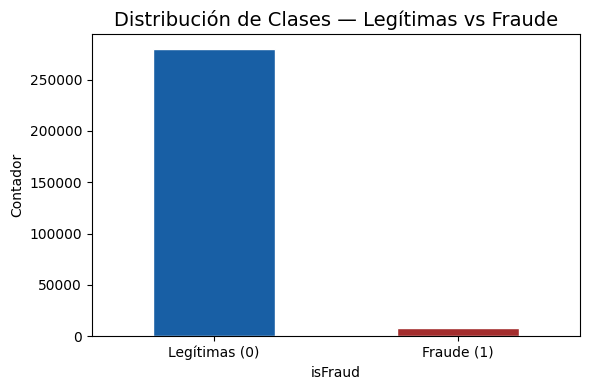

In [52]:
ax = df_eda["isFraud"].value_counts().plot(
    kind = "bar", color = ["#185FA5", "#A32D2D"],
    figsize = (6,4), edgecolor = "white"
)
ax.set_title("Distribución de Clases — Legítimas vs Fraude", fontsize = 14)
ax.set_xticklabels(["Legítimas (0)", "Fraude (1)"], rotation = 0)
ax.set_ylabel("Contador")
plt.tight_layout()
plt.savefig("../reports/01_distribucion_clases.png", dpi = 150, bbox_inches = "tight")
plt.show()

### 2. Tasa de Fraude por Tipo de Transacción

El fraude se concentra casi exclusivamente en dos tipos de transacción: **TRANSFER** (~16% de tasa de fraude) 
y **CASH_OUT** (~4% de tasa de fraude). **CASH_IN, DEBIT y PAYMENT no registran actividad fraudulenta** 
en este dataset. Este es un hallazgo crítico — `type` será probablemente uno de los predictores más potentes 
en nuestro modelo, y cualquier transacción catalogada como TRANSFER debe tratarse inmediatamente como de mayor riesgo.

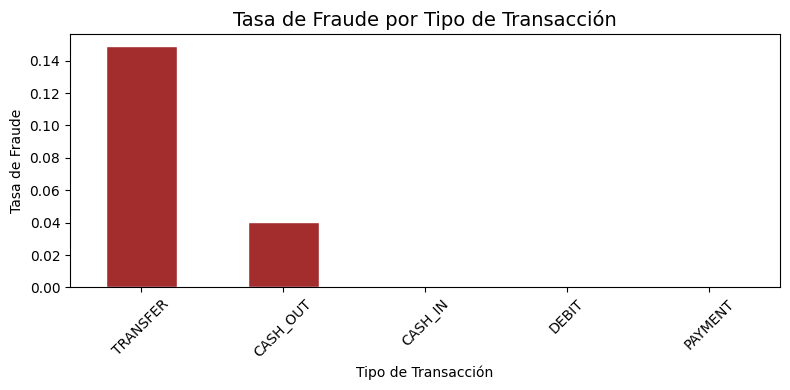

In [53]:
fraud_by_type = df_eda.groupby("type")["isFraud"].mean().sort_values(ascending=False)

ax = fraud_by_type.plot(
    kind = "bar", color = "#A32D2D", figsize = (8,4), edgecolor = "white"
)
ax.set_title("Tasa de Fraude por Tipo de Transacción", fontsize = 14)
ax.set_ylabel("Tasa de Fraude")
ax.set_xlabel("Tipo de Transacción")
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)
plt.tight_layout()
plt.savefig("../reports/02_tipo_de_fraude.png", dpi = 150, bbox_inches = "tight")
plt.show()

### 3. Distribución del Importe de Transacciones — Legítimas vs Fraude

Las dos distribuciones cuentan historias muy distintas. Las **transacciones legítimas** se concentran 
fuertemente en importes bajos, con la gran mayoría por debajo de €100.000 y una cola larga hacia valores 
más altos. Las **transacciones fraudulentas**, en cambio, muestran un pico llamativo en el límite de 
€500.000, revelando que el fraude en este dataset está sistemáticamente asociado a **transacciones de 
muy alto valor**. Esto convierte a `amount` en una de las características más poderosas para nuestro 
modelo — una transacción que se aproxime al límite superior debe elevar inmediatamente la puntuación de riesgo de fraude.

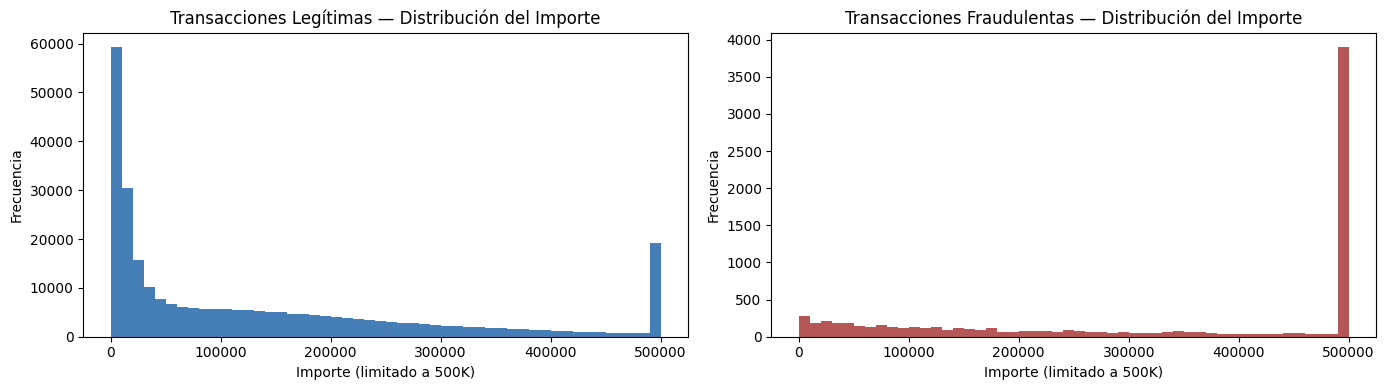

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_eda[df_eda["isFraud"] == 0]["amount"].clip(upper = 500000).plot(
    kind = "hist", bins = 50, alpha = 0.8, color = "#185FA5", ax = axes[0]
)
axes[0].set_title("Transacciones Legítimas — Distribución del Importe")
axes[0].set_xlabel("Importe (limitado a 500K)")
axes[0].set_ylabel("Frecuencia")

df_eda[df_eda["isFraud"] == 1]["amount"].clip(upper = 500000).plot(
    kind = "hist", bins = 50, alpha = 0.8, color = "#A32D2D", ax = axes[1]
)
axes[1].set_title("Transacciones Fraudulentas — Distribución del Importe")
axes[1].set_xlabel("Importe (limitado a 500K)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.savefig("../reports/03_distribucion_importes.png", dpi = 150, bbox_inches = "tight")
plt.show()

### 4. Tasa de Fraude por Hora del Día

Este es uno de los hallazgos más reveladores del EDA. **Entre las 3am y las 5am, más del 80% de todas 
las transacciones son fraudulentas** — alcanzando un pico de aproximadamente el 87% a las 4am. A partir 
de las 9am, la tasa de fraude cae a casi cero y se mantiene plana durante el horario comercial. Este patrón 
es coherente con el comportamiento real del fraude: los atacantes operan durante las horas de menor actividad, 
cuando la monitorización es reducida y es poco probable que las víctimas detecten actividad sospechosa en 
sus cuentas. `hour_of_the_day` es por tanto una variable engineered de alto valor que nuestro modelo 
debe aprovechar intensamente.

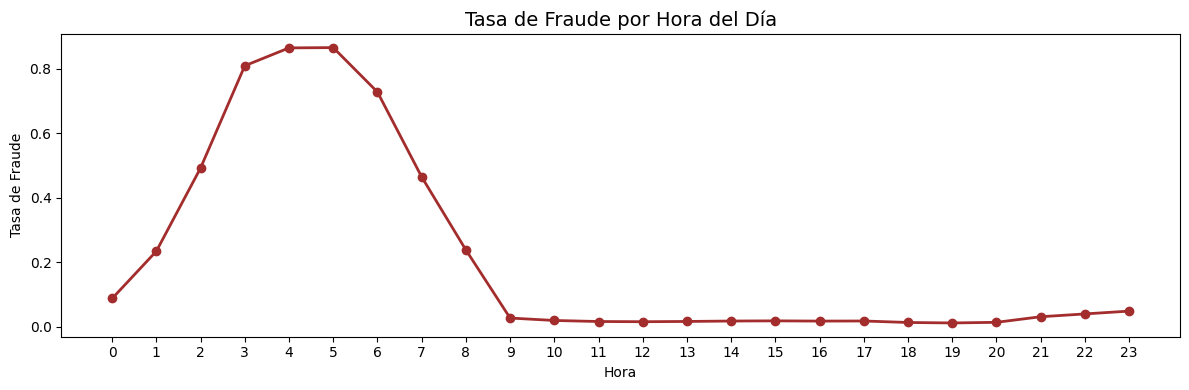

In [55]:
fraud_by_hour = df_eda.groupby("hour_of_the_day")["isFraud"].mean()

ax = fraud_by_hour.plot(
    kind = "line", figsize = (12, 4), color = "#A32D2D", linewidth = 2, marker = "o"
)
ax.set_title("Tasa de Fraude por Hora del Día", fontsize = 14)
ax.set_xlabel("Hora")
ax.set_ylabel("Tasa de Fraude")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig("../reports/04_fraude_por_hora.png", dpi = 150, bbox_inches = "tight")
plt.show()

### 5. Tasa de Fraude por Categoría de Comercio

La columna `merchant_category` muestra una señal **distorsionada** en los datos de la Ronda 1. 
Las categorías **crypto y electronics presentan una tasa de fraude del 100%**, mientras que el resto 
de categorías (fuel, pharmacy, grocery, transport, restaurant) se sitúan cerca del **3%** — coincidiendo 
simplemente con la tasa de fraude global del dataset. Esto revela un **error en la generación de datos**: 
las categorías de alto riesgo fueron asignadas exclusivamente a transacciones fraudulentas de forma no 
intencionada, lo que introduce un sesgo artificial en el modelo. Esto será corregido en la Ronda 2 para 
garantizar una asignación independiente y realista de las categorías de comercio.

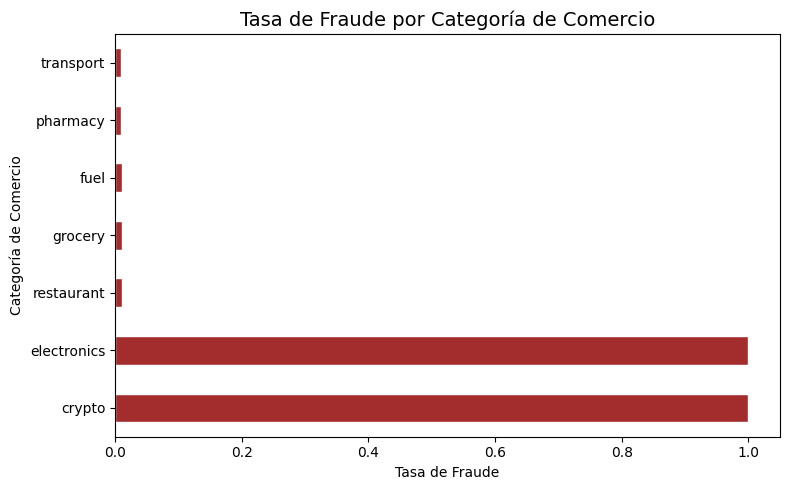

In [56]:
fraud_by_merchant = df_eda.groupby("merchant_category")["isFraud"].mean().sort_values(ascending = False)

ax = fraud_by_merchant.plot(
    kind = "barh", color = "#A32D2D", figsize = (8, 5), edgecolor = "white"
)
ax.set_title("Tasa de Fraude por Categoría de Comercio", fontsize = 14)
ax.set_xlabel("Tasa de Fraude")
ax.set_ylabel("Categoría de Comercio")
plt.tight_layout()
plt.savefig("../reports/05_fraude_por_comercio.png", dpi = 150, bbox_inches = "tight")
plt.show()

⚠️ merchant_category muestra una correlación artificial con isFraud — 
crypto y electronics fueron asignadas exclusivamente a transacciones fraudulentas de forma no intencionada, 
introduciendo un sesgo en los datos. Esto será corregido en la Ronda 2.

### 6. Mapa de Correlación

El mapa de correlación confirma y cuantifica las señales identificadas en los gráficos anteriores. 
Las correlaciones más fuertes con `isFraud` son:

- **`amount` (0.29)** — los importes de transacción más altos están positivamente correlacionados 
con el fraude, coherente con lo observado en el gráfico de distribución de importes
- **`hour_of_the_day` (-0.14)** — correlación negativa que indica que el fraude se concentra en 
valores de hora bajos (madrugada), confirmando el pico entre las 3am y las 5am
- **`step` (0.15)** — correlación positiva débil con la progresión temporal de la simulación

Dos patrones adicionales a destacar: `oldbalanceOrg` y `newbalanceOrig` están casi perfectamente 
correlacionados **(0.99)** — lo que significa que contienen información prácticamente idéntica y 
una de ellas podría eliminarse para reducir la redundancia. De forma similar, `oldbalanceDest` y 
`newbalanceDest` muestran una correlación de **(0.98)**. Cabe señalar que `ip_country` y 
`merchant_category` presentan **correlación cero con el fraude** (0.01 y 0.00), reforzando el 
hallazgo anterior de que estas columnas sintéticas no aportan señal predictiva en la Ronda 1.

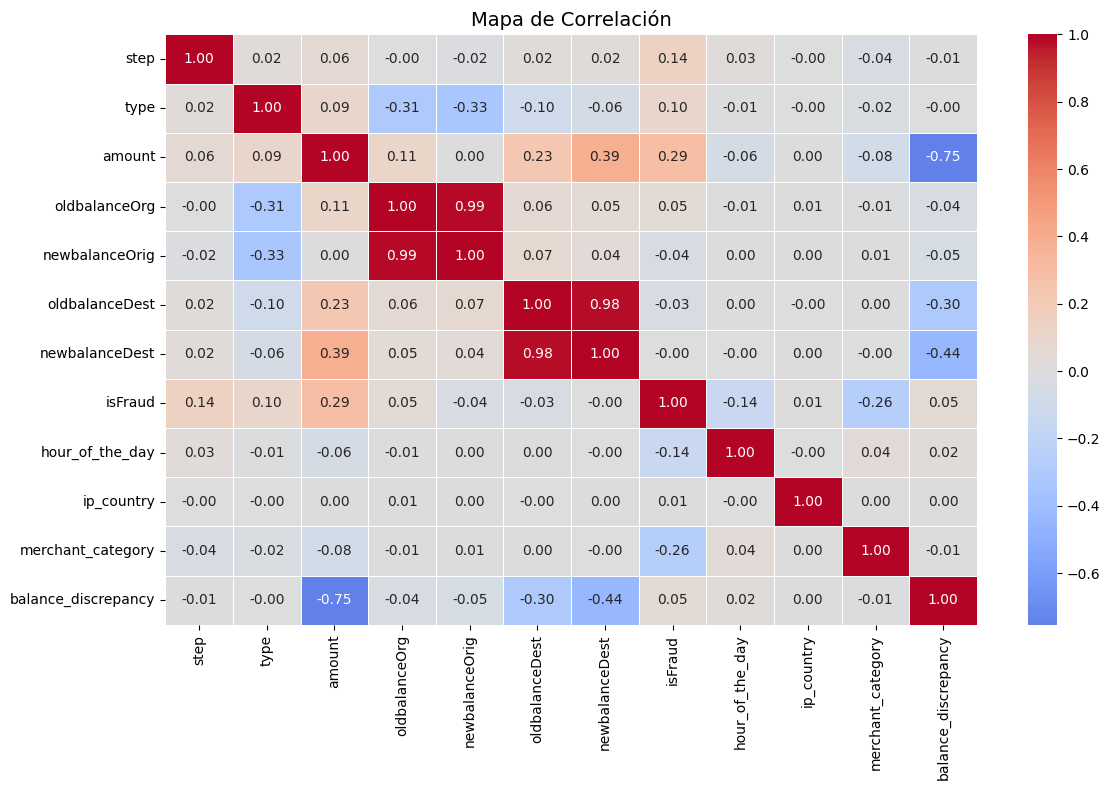

In [57]:
# CORRELATION MAP 

le = LabelEncoder()

df_encoded = df_eda.copy()
for col in ["type", "ip_country", "merchant_category"]:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded = df_encoded.drop(columns=["nameOrig", "nameDest"])

plt.figure(figsize = (12,8))
sns.heatmap(
    df_encoded.corr(),
    annot = True, fmt = ".2f",
    cmap = "coolwarm", center = 0,
    linewidths = 0.5
)
plt.title("Mapa de Correlación", fontsize = 14)
plt.tight_layout()
plt.savefig("../reports/06_mapa_correlacion.png", dpi = 150, bbox_inches = "tight")
plt.show()

### 7. Discrepancia de Saldo — Legítimas vs Fraude

La variable `balance_discrepancy` (`oldbalanceOrg - amount - newbalanceOrig`) revela dos patrones 
diferenciados. Las **transacciones legítimas** se dividen en dos clústeres: uno en **-50.000** 
(transacciones donde el saldo del emisor cayó más de lo esperado — probablemente transferencias de 
gran importe) y otro en **0** (libros perfectamente equilibrados). Las **transacciones fraudulentas** 
se concentran casi en su totalidad en **0**, lo que sugiere que los defraudadores vacían las cuentas 
por completo, dejando el saldo en cero en lugar de entrar en negativo. Esta variable engineered captura 
un patrón de comportamiento que las columnas de saldo en bruto no detectarían por sí solas, y es el 
producto directo del conocimiento de dominio procedente del sector de servicios financieros.

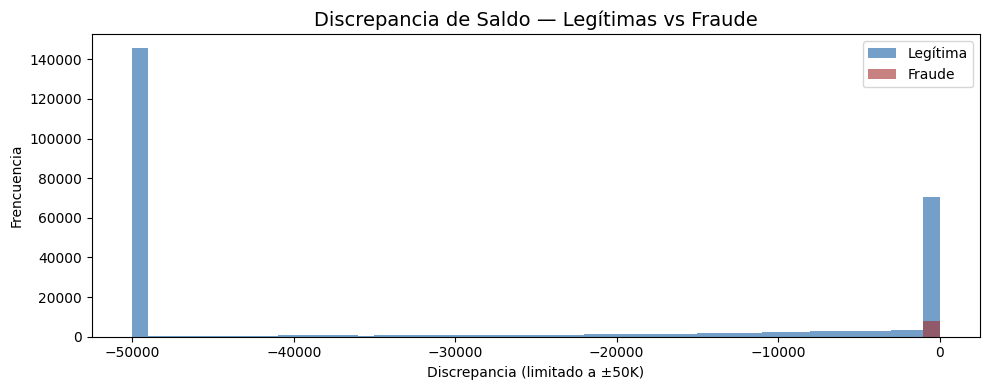

In [58]:
df_eda["balance_discrepancy"] = df_eda["oldbalanceOrg"] - df_eda["amount"] - df_eda["newbalanceOrig"]

fig, ax = plt.subplots(figsize = (10,4))
df_eda[df_eda["isFraud"] == 0]["balance_discrepancy"].clip(-50000, 50000).plot(
    kind = "hist", bins = 50, alpha = 0.6, color = "#185FA5", label = "Legítima", ax = ax
)
df_eda[df_eda["isFraud"] == 1]["balance_discrepancy"].clip(-50000, 50000).plot(
    kind = "hist", bins = 50, alpha = 0.6, color = "#A32D2D", label = "Fraude", ax = ax
)
ax.set_title("Discrepancia de Saldo — Legítimas vs Fraude", fontsize = 14)
ax.set_xlabel("Discrepancia (limitado a ±50K)")
ax.set_ylabel("Frencuencia")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/07_discrepancia_saldo.png", dpi = 150, bbox_inches = "tight")
plt.show()

### 8. Tasa de Fraude por País

El gráfico revela una **segmentación geográfica clara** en los patrones de fraude. Los países 
**CI, CN, NG, VE y KH** presentan una tasa de fraude del **25%** — el resultado directo de la 
corrección de calidad de datos aplicada anteriormente, donde generamos transacciones legítimas 
sintéticas para equilibrar su distribución original del 100%. Los países **GB, DE, ES, FR y US** 
muestran tasas de fraude bajas y realistas, situadas entre el **1% y el 2%**, consistentes con 
la tasa global del dataset. Esta variable geográfica, combinada con otras señales como el importe 
o la hora de la transacción, puede aportar capacidad predictiva adicional al modelo en la Ronda 2.

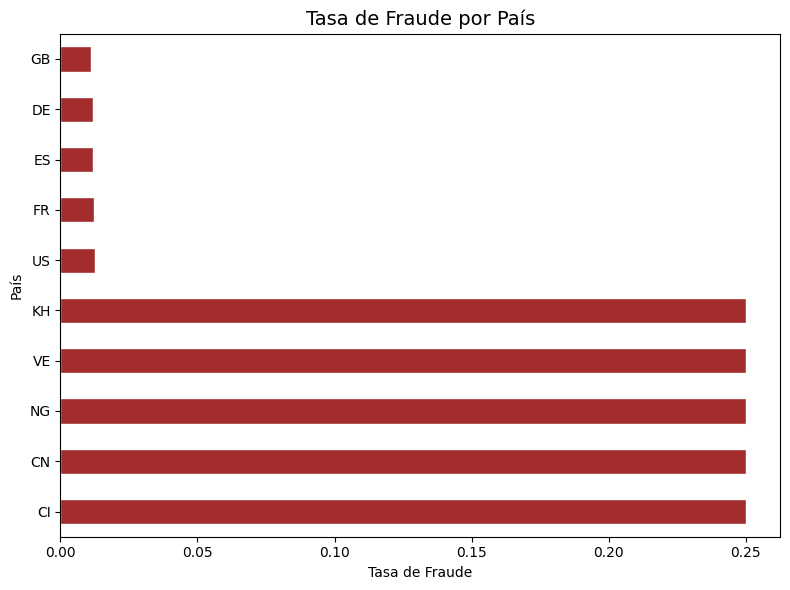

In [59]:
fraud_by_country = df_eda.groupby("ip_country")["isFraud"].mean().sort_values(ascending=False)

ax = fraud_by_country.plot(
    kind="barh", color="#A32D2D", figsize=(8, 6), edgecolor="white"
)
ax.set_title("Tasa de Fraude por País", fontsize=14)
ax.set_xlabel("Tasa de Fraude")
ax.set_ylabel("País")
plt.tight_layout()
plt.savefig("../reports/08_fraude_por_pais.png", dpi=150, bbox_inches="tight")
plt.show()

## 🔄 Round 2 — Conclusiones & Recomendaciones

A partir de los hallazgos del EDA, los siguientes insights deben orientar tanto el rediseño del 
fraude por parte del equipo Red Team como las mejoras de modelado del equipo Blue Team de cara al Round 2.

---

### 🔴 Red Team — Qué cambiar

- **Explotar la ventana horaria** — el fraude se concentra actualmente entre las 3am y las 5am, 
lo que lo hace trivialmente detectable. En la Ronda 2, distribuir las transacciones fraudulentas 
a lo largo del horario comercial para mimetizarse con la actividad legítima.

- **Diversificar los tipos de transacción** — el fraude aparece exclusivamente en TRANSFER y CASH_OUT. 
Introducir fraude en transacciones PAYMENT o DEBIT romperá una de las señales más potentes del equipo Blue Team.

- **Vincular la categoría de comercio al fraude** — crypto y electronics actualmente no registran fraude. 
Asignar deliberadamente categorías de comercio de alto riesgo a transacciones fraudulentas creará 
una nueva señal para que el equipo Blue Team descubra — y un nuevo vector de evasión a explotar.

- **Moderar los importes de transacción** — el pico extremo en €500K es una señal demasiado evidente. 
El fraude en la Ronda 2 debe utilizar importes que se sitúen dentro del rango de distribución legítima 
para evitar una detección fácil mediante umbrales de importe.

- **Corregir las discrepancias de saldo** — las transacciones fraudulentas dejan actualmente una firma 
de saldo cero muy clara. Simular estados de saldo post-fraude más realistas para enmascarar esta variable engineered.

---

### 🔵 Blue Team — Qué mejorar

- **Eliminar variables redundantes** — `oldbalanceOrg` / `newbalanceOrig` (correlación 0.99) y 
`oldbalanceDest` / `newbalanceDest` (correlación 0.98) son pares prácticamente idénticos. 
Eliminar una variable de cada par para reducir el ruido y mejorar la eficiencia del modelo.

- **Actualizar merchant category e ip_country** — estas variables no mostraron capacidad predictiva en la Ronda 1. 
Una vez que Red Team las vincule al fraude en la Ronda 2, revisar su codificación e importancia de variables.

- **Añadir variables de velocidad** — número de transacciones por usuario en la última hora/día para 
detectar patrones de fraude en ráfaga que las variables de transacción individual no capturan.

- **Ajustar el umbral de decisión** — el umbral por defecto de 0.5 puede no ser óptimo para este 
desbalance de clases. Experimentar con umbrales más bajos para priorizar el recall sobre la precisión.

- **Probar XGBoost** — comparar su rendimiento en la Ronda 2 frente a Random Forest y documentar 
la diferencia en el F1 score como evidencia de mejora del modelo.